# RAG 과제: 4가지 검색 방식 비교 분석

## 과제 목표
- **핵심 목표**: 4-5주차 핵심을 한 번에 체득
- **Retrieval 비교**: Dense(벡터) vs BM25(키워드) vs Hybrid(융합) vs Hybrid+Re-rank(CE)
- **품질 향상 체감**: 하이브리드/재순위화가 정답 포함률·상위정밀도를 어떻게 끌어올리는지 수치로 확인
- **근거 중심 출력**: 최종 답에 근거 스니펫·출처를 함께 표시

## 데이터셋
- **기본**: KorQuAD 2.0 미니셋 (문서 500-2,000청크 규모)
- **도구 스택**: Pinecone + BGE-M3 + BM25 + BGE Reranker

## 4가지 검색 조건
1. **Dense 전용**: Pinecone top-k
2. **BM25 전용**: rank-bm25 색인 후 top-k  
3. **Hybrid(융합)**: RRF(순위 역수합) 또는 가중합
4. **Hybrid + Re-rank**: Top-N=100 후보를 Cross-Encoder로 재점수 → Top-k=5~10 확정


## 1. 환경 설정 및 라이브러리 설치


In [27]:
# 필요한 라이브러리 설치
%pip -q install -U python-dotenv requests pinecone pinecone-text FlagEmbedding datasets rank_bm25 matplotlib tqdm pandas numpy scikit-learn


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip available: 22.2.2 -> 25.2
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import json
import time
import math
import random
import re
import pickle
from typing import List, Dict, Any, Tuple
from collections import defaultdict
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from dotenv import load_dotenv

# 데이터셋 및 임베딩
from datasets import load_dataset
from FlagEmbedding import BGEM3FlagModel, FlagReranker
from rank_bm25 import BM25Okapi

# Pinecone
from pinecone import Pinecone, ServerlessSpec
from pinecone_text.sparse import BM25Encoder

# 환경 변수 로드
load_dotenv()

# 환경 변수 설정
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY", "")
PC_CLOUD = os.getenv("PC_CLOUD", "aws")
PC_REGION = os.getenv("PC_REGION", "us-east-1")
INDEX_NAME = os.getenv("PC_INDEX_NAME", "rag-assignment-korquad")
METRIC = os.getenv("PC_METRIC", "dotproduct")

# 실습 스케일 설정
CORPUS_MAX = int(os.getenv("CORPUS_MAX", "2000"))
N_QUERIES = int(os.getenv("N_QUERIES", "50"))

# α 프리셋 (하이브리드 가중치)
ALPHA_PRESETS = {"balanced": 0.5, "semantic_heavy": 0.7, "keyword_heavy": 0.3}
ALPHA = float(os.getenv("ALPHA", ALPHA_PRESETS["balanced"]))

# N/k 템플릿 (검색 후보 수 / 최종 반환 수)
TEMPLATES = {
    "speed": {"N": 50, "k": 3},
    "balanced": {"N": 100, "k": 5},
    "quality": {"N": 200, "k": 10}
}
N = int(os.getenv("RETRIEVER_N", TEMPLATES["balanced"]["N"]))
K = int(os.getenv("LLM_K", TEMPLATES["balanced"]["k"]))

print("환경 설정 완료:")
print(f"Pinecone: {INDEX_NAME} {PC_CLOUD} {PC_REGION} {METRIC}")
print(f"Scale: {CORPUS_MAX} {N_QUERIES} | α={ALPHA} N={N} K={K}")
assert PINECONE_API_KEY, "PINECONE_API_KEY is required (set in .env)"


/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


환경 설정 완료:
Pinecone: rag-assignment-korquad aws us-east-1 dotproduct
Scale: 2000 50 | α=0.5 N=100 K=5


## 2. 데이터 준비 및 전처리


In [4]:
# KorQuAD 2.0 데이터셋 로드
print("KorQuAD 2.0 데이터셋 로딩 중...")
raw_dataset = load_dataset("leeseeun/KorQuAD_2.0", split="train")

# 실제 컬럼 구조 확인
print("데이터셋 구조:", raw_dataset.features)
print("첫 번째 샘플:", raw_dataset[0])

# 데이터 정규화 함수
def normalize_sample(x):
    """KorQuAD 샘플을 정규화"""
    q = x.get("question", "").strip()
    ctx = x.get("text", "").strip()  
    ans = x.get("answer", "").strip() 
    
    return {"question": q, "context": ctx, "answer": ans}

# 데이터셋 정규화 및 샘플링
dataset = raw_dataset.map(normalize_sample)
dataset = dataset.shuffle(seed=42).select(range(min(CORPUS_MAX, len(dataset))))

print(f"로드된 데이터: {len(dataset)}개 샘플")
print("샘플 예시:")
print(dataset[0])

KorQuAD 2.0 데이터셋 로딩 중...
데이터셋 구조: {'question': Value('string'), 'answer': Value('string'), 'text': Value('string')}
첫 번째 샘플: {'question': '드라마 예고범의 감독은 누구일까?', 'answer': '나카무라 요시히로, 히라바야시 카츠토시, 사와다 메구미', 'text': '## 질문: 드라마 예고범의 감독은 누구일까?\n## 답변: 나카무라 요시히로, 히라바야시 카츠토시, 사와다 메구미\n\n'}


Map: 100%|██████████| 83486/83486 [00:02<00:00, 41474.27 examples/s]

로드된 데이터: 2000개 샘플
샘플 예시:
{'question': '유럽찌르레기의 울음 소리와 비슷한 조류는 무엇인가?', 'answer': '수탉', 'text': '## 질문: 유럽찌르레기의 울음 소리와 비슷한 조류는 무엇인가?\n## 답변: 수탉\n\n', 'context': '## 질문: 유럽찌르레기의 울음 소리와 비슷한 조류는 무엇인가?\n## 답변: 수탉'}


In [5]:
# 청크 생성 함수
def create_chunks(text: str, max_chars: int = 800, overlap_chars: int = 120) -> List[str]:
    """문단 기반 청크 생성 (겹침 포함)"""
    if not text:
        return []
    
    # 문단 단위로 분할
    paras = [p.strip() for p in re.split(r'(?:\r?\n){2,}', text) if p.strip()]
    if not paras:
        paras = [text.strip()]
    
    chunks = []
    for para in paras:
        if len(para) <= max_chars:
            chunks.append(para)
        else:
            # 긴 문단은 슬라이딩 윈도우로 분할
            start = 0
            while start < len(para):
                end = min(start + max_chars, len(para))
                chunks.append(para[start:end])
                if end >= len(para):
                    break
                start = max(0, end - overlap_chars)
    
    return chunks

# 코퍼스 생성
corpus = []
skipped = 0

print("청크 생성 중...")
for i, row in enumerate(tqdm(dataset)):
    ctx = row["text"]
    if not ctx:
        skipped += 1
        continue
    
    chunks = create_chunks(ctx)
    for j, chunk in enumerate(chunks):
        corpus.append({
            "id": f"doc-{i}-chunk-{j}",
            "text": chunk,
            "metadata": {
                "source": "KorQuAD2.0",
                "doc_id": f"doc-{i}",
                "chunk_id": j,
                "language": "ko",
                "question": row["question"],
                "answer": row["answer"]
            }
        })

print(f"생성된 청크: {len(corpus)}개 (건너뛴 샘플: {skipped}개)")
if corpus:
    print("청크 예시:")
    print(f"ID: {corpus[0]['id']}")
    print(f"텍스트: {corpus[0]['text'][:200]}...")


청크 생성 중...


100%|██████████| 2000/2000 [00:00<00:00, 27767.75it/s]

생성된 청크: 2034개 (건너뛴 샘플: 0개)
청크 예시:
ID: doc-0-chunk-0
텍스트: ## 질문: 유럽찌르레기의 울음 소리와 비슷한 조류는 무엇인가?
## 답변: 수탉...


## 3. 임베딩 및 인덱싱


In [6]:
# BGE-M3 모델 로드 (Dense + Sparse 임베딩)
print("BGE-M3 모델 로딩 중...")
bge_model = BGEM3FlagModel("BAAI/bge-m3", use_fp16=False, devices="mps")

# 텍스트 추출
texts = [chunk["text"] for chunk in corpus]
print(f"임베딩할 텍스트: {len(texts)}개")

# Dense 임베딩 생성
print("Dense 임베딩 생성 중...")
dense_embeddings = []
batch_size = 32

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]
    embeddings = bge_model.encode(
        batch,
        batch_size=batch_size,
        max_length=1024,
        return_dense=True,
        return_sparse=False,
        return_colbert_vecs=False
    )
    
    # L2 정규화
    dense_vecs = embeddings["dense_vecs"]
    dense_vecs = dense_vecs / np.linalg.norm(dense_vecs, axis=1, keepdims=True)
    dense_embeddings.extend(dense_vecs)

dense_embeddings = np.array(dense_embeddings).astype("float32")
print(f"Dense 임베딩 완료: {dense_embeddings.shape}")

# BM25 인코더 학습
print("BM25 인코더 학습 중...")

# 빈 텍스트 필터링
valid_texts = [t for t in texts if t and t.strip()]
print(f"유효한 텍스트: {len(valid_texts)}개 (전체: {len(texts)}개)")

if len(valid_texts) == 0:
    raise ValueError("유효한 텍스트가 없습니다. 데이터 전처리를 확인하세요.")

# corpus도 유효한 텍스트와 동일한 인덱스만 유지
if len(valid_texts) != len(texts):
    valid_corpus = []
    for i, t in enumerate(texts):
        if t and t.strip():
            valid_corpus.append(corpus[i])
    corpus = valid_corpus
    texts = valid_texts
    # dense_embeddings도 동일하게 필터링
    dense_embeddings = dense_embeddings[:len(valid_texts)]
    print(f"corpus와 dense_embeddings를 {len(valid_texts)}개로 조정")

bm25_encoder = BM25Encoder()
bm25_encoder.fit(texts)
sparse_vectors = bm25_encoder.encode_documents(texts)

# BM25 인코더 저장
os.makedirs("artifacts", exist_ok=True)
with open("artifacts/bm25_encoder.pkl", "wb") as f:
    pickle.dump(bm25_encoder, f)

print(f"BM25 인코딩 완료: {len(sparse_vectors)}개")


BGE-M3 모델 로딩 중...


Fetching 30 files: 100%|██████████| 30/30 [00:00<00:00, 28168.60it/s]


임베딩할 텍스트: 2034개
Dense 임베딩 생성 중...


pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 75.86it/s]
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
100%|██████████| 64/64 [14:59<00:00, 14.06s/it]


Dense 임베딩 완료: (2034, 1024)
BM25 인코더 학습 중...
유효한 텍스트: 2034개 (전체: 2034개)


100%|██████████| 2034/2034 [00:00<00:00, 2482.80it/s]


BM25 인코딩 완료: 2034개


In [7]:
# Pinecone 인덱스 생성 및 업서트
print("Pinecone 인덱스 설정 중...")
pc = Pinecone(api_key=PINECONE_API_KEY)

# 인덱스가 없으면 생성
if INDEX_NAME not in [idx["name"] for idx in pc.list_indexes()]:
    print(f"인덱스 생성 중: {INDEX_NAME}")
    pc.create_index(
        name=INDEX_NAME,
        dimension=dense_embeddings.shape[1],
        metric=METRIC,
        spec=ServerlessSpec(cloud=PC_CLOUD, region=PC_REGION)
    )
    time.sleep(10)  # 인덱스 준비 대기
else:
    print(f"기존 인덱스 사용: {INDEX_NAME}")

index = pc.Index(INDEX_NAME)
print("인덱스 상태:", index.describe_index_stats())

# 벡터 업서트
print("벡터 업서트 중...")
batch_size = 200
for i in tqdm(range(0, len(corpus), batch_size)):
    batch = []
    for j in range(i, min(i + batch_size, len(corpus))):
        chunk = corpus[j]
        batch.append({
            "id": chunk["id"],
            "values": dense_embeddings[j].tolist(),
            "sparse_values": sparse_vectors[j],
            "metadata": chunk["metadata"]
        })
    
    if batch:
        index.upsert(vectors=batch)

print("업서트 완료!")
print("최종 인덱스 상태:", index.describe_index_stats())


Pinecone 인덱스 설정 중...
기존 인덱스 사용: rag-assignment-korquad
인덱스 상태: {'dimension': 1024,
 'index_fullness': 0.0,
 'metric': 'dotproduct',
 'namespaces': {'': {'vector_count': 2034}},
 'total_vector_count': 2034,
 'vector_type': 'dense'}
벡터 업서트 중...


100%|██████████| 11/11 [00:13<00:00,  1.25s/it]


업서트 완료!
최종 인덱스 상태: {'dimension': 1024,
 'index_fullness': 0.0,
 'metric': 'dotproduct',
 'namespaces': {'': {'vector_count': 2034}},
 'total_vector_count': 2034,
 'vector_type': 'dense'}


## 4. 4가지 검색 방식 구현


In [15]:
# 검색 함수들 구현

def encode_query_dense(query: str) -> np.ndarray:
    """쿼리를 dense 벡터로 인코딩"""
    embeddings = bge_model.encode([query], max_length=1024, return_dense=True)
    dense_vec = embeddings["dense_vecs"][0]
    return (dense_vec / np.linalg.norm(dense_vec)).astype("float32")

def encode_query_sparse(query: str) -> Dict:
    """쿼리를 sparse 벡터로 인코딩"""
    return bm25_encoder.encode_queries([query])[0]

def dense_search(query: str, top_k: int = N) -> List[Dict]:
    """1. Dense 전용 검색"""
    dense_vector = encode_query_dense(query).tolist()
    results = index.query(
        vector=dense_vector,
        top_k=top_k,
        include_metadata=True
    )
    return results.matches

def sparse_search(query: str, top_k: int = N) -> List[Dict]:
    """2. BM25 전용 검색"""
    # Pinecone에서 dense-only 인덱스에 sparse_vector만 전달하면 400 에러가 발생하므로,
    # dense vector를 0으로 채워서 함께 전달해야 함
    sparse_vector = encode_query_sparse(query)
    # dense vector의 차원은 인덱스 생성 시 dimension과 동일해야 함
    zero_dense = [0.0] * dense_embeddings.shape[1]
    results = index.query(
        vector=zero_dense,
        sparse_vector=sparse_vector,
        top_k=top_k,
        include_metadata=True
    )
    return results.matches

def hybrid_weighted_search(query: str, top_k: int = N, alpha: float = ALPHA) -> List[Dict]:
    """3. Hybrid 검색 (가중합)"""
    dense_vector = encode_query_dense(query)
    sparse_vector = encode_query_sparse(query)
    
    # 가중치 적용
    dense_vector = (dense_vector * alpha).tolist()
    sparse_vector_scaled = {
        "indices": sparse_vector["indices"],
        "values": [v * (1.0 - alpha) for v in sparse_vector["values"]]
    }
    
    results = index.query(
        vector=dense_vector,
        sparse_vector=sparse_vector_scaled,
        top_k=top_k,
        include_metadata=True
    )
    return results.matches

def rrf_fusion(query: str, top_k: int = N, per_list_k: int = 100, k_const: int = 60) -> List[Dict]:
    """RRF (Reciprocal Rank Fusion) 융합"""
    # 각 방법으로 검색
    dense_results = dense_search(query, top_k=per_list_k)
    sparse_results = sparse_search(query, top_k=per_list_k)
    
    # RRF 점수 계산
    doc_scores = defaultdict(list)
    doc_metadata = {}
    
    for rank, result in enumerate(dense_results, 1):
        doc_id = result.id
        doc_scores[doc_id].append(rank)
        doc_metadata[doc_id] = result.metadata
    
    for rank, result in enumerate(sparse_results, 1):
        doc_id = result.id
        doc_scores[doc_id].append(rank)
        doc_metadata[doc_id] = result.metadata
    
    # RRF 점수 계산 및 정렬
    rrf_scores = []
    for doc_id, ranks in doc_scores.items():
        rrf_score = sum(1.0 / (k_const + rank) for rank in ranks)
        rrf_scores.append({
            "id": doc_id,
            "score": rrf_score,
            "metadata": doc_metadata[doc_id]
        })
    
    rrf_scores.sort(key=lambda x: x["score"], reverse=True)
    return rrf_scores[:top_k]

print("검색 함수들 구현 완료!")


검색 함수들 구현 완료!


In [16]:
# Re-ranker 모델 로드
print("BGE Reranker 모델 로딩 중...")
reranker = FlagReranker("BAAI/bge-reranker-v2-m3", use_fp16=False)

def rerank_candidates(query: str, candidates: List[Dict], top_k: int = K) -> List[Dict]:
    """4. Cross-Encoder를 이용한 재순위화"""
    if not candidates:
        return []
    
    # 쿼리-문서 쌍 생성
    pairs = []
    id_to_metadata = {}
    
    for candidate in candidates:
        if hasattr(candidate, 'id'):
            doc_id = candidate.id
            metadata = candidate.metadata
        else:
            doc_id = candidate["id"]
            metadata = candidate.get("metadata", {})
        
        # 문서 텍스트 추출 (metadata에서 또는 corpus에서)
        doc_text = metadata.get("text", "")
        if not doc_text:
            # corpus에서 찾기
            for chunk in corpus:
                if chunk["id"] == doc_id:
                    doc_text = chunk["text"]
                    break
        
        pairs.append([query, doc_text])
        id_to_metadata[doc_id] = metadata
    
    # Cross-Encoder로 점수 계산
    if not pairs:
        return []
    
    scores = reranker.compute_score(pairs)
    
    # 결과 정렬
    results = []
    for i, (doc_id, score) in enumerate(zip(id_to_metadata.keys(), scores)):
        results.append({
            "id": doc_id,
            "score": float(score),
            "metadata": id_to_metadata[doc_id]
        })
    
    results.sort(key=lambda x: x["score"], reverse=True)
    return results[:top_k]

def hybrid_rerank_search(query: str, top_n: int = N, top_k: int = K) -> List[Dict]:
    """4. Hybrid + Re-rank 검색"""
    # 1단계: Hybrid 검색으로 후보 수집
    candidates = hybrid_weighted_search(query, top_k=top_n)
    
    # 2단계: Cross-Encoder로 재순위화
    reranked = rerank_candidates(query, candidates, top_k=top_k)
    
    return reranked

print("Re-ranker 구현 완료!")


BGE Reranker 모델 로딩 중...
Re-ranker 구현 완료!


## 5. 평가 및 시각화


In [25]:
# 평가 지표 계산 함수들

def get_text_from_result(result) -> str:
    """검색 결과에서 텍스트 추출"""
    # doc_id 추출
    if hasattr(result, 'id'):
        doc_id = result.id
    else:
        doc_id = result.get('id', '')
    
    # corpus에서 텍스트 찾기
    for chunk in corpus:
        if chunk['id'] == doc_id:
            return chunk['text']
    
    # 찾지 못한 경우 metadata에서 시도
    if hasattr(result, 'metadata'):
        return result.metadata.get('text', '')
    else:
        return result.get('metadata', {}).get('text', '')

def calculate_recall_at_k(results: List[Dict], ground_truth: str, k: int = 5) -> float:
    """Recall@k 계산"""
    if not ground_truth or not results:
        return 0.0
    
    top_k_results = results[:k]
    for result in top_k_results:
        text = get_text_from_result(result)
        
        if ground_truth.lower() in text.lower():
            return 1.0
    
    return 0.0

def calculate_mrr(results: List[Dict], ground_truth: str) -> float:
    """MRR (Mean Reciprocal Rank) 계산"""
    if not ground_truth or not results:
        return 0.0
    
    for i, result in enumerate(results, 1):
        text = get_text_from_result(result)
        
        if ground_truth.lower() in text.lower():
            return 1.0 / i
    
    return 0.0

def calculate_ndcg_at_k(results: List[Dict], ground_truth: str, k: int = 10) -> float:
    """NDCG@k 계산 (간단 버전)"""
    if not ground_truth or not results:
        return 0.0
    
    top_k_results = results[:k]
    relevance_scores = []
    
    for result in top_k_results:
        text = get_text_from_result(result)
        
        # 간단한 관련성 점수 (정답 포함 여부)
        if ground_truth.lower() in text.lower():
            relevance_scores.append(1.0)
        else:
            relevance_scores.append(0.0)
    
    # NDCG 계산
    dcg = 0.0
    for i, rel in enumerate(relevance_scores):
        dcg += rel / math.log2(i + 2)  # i+2 because log2(1) = 0
    
    # IDCG (이상적인 DCG)
    idcg = sum(1.0 / math.log2(i + 2) for i in range(min(len(relevance_scores), k)))
    
    return dcg / idcg if idcg > 0 else 0.0

def evaluate_single_method(method_name: str, search_func, queries: List[str], ground_truths: List[str], k_values: List[int] = [5, 10]) -> Dict:
    """단일 검색 방법 평가"""
    print(f"{method_name} 방법 평가 중...")
    method_results = {
        "recall": {f"@{k}": [] for k in k_values},
        "mrr": [],
        "ndcg": {f"@{k}": [] for k in k_values}
    }
    
    for query, gt in tqdm(zip(queries, ground_truths), total=len(queries), desc=method_name):
        try:
            # 검색 실행
            search_results = search_func(query, top_k=max(k_values))
            
            # 각 지표 계산
            for k in k_values:
                recall = calculate_recall_at_k(search_results, gt, k)
                method_results["recall"][f"@{k}"].append(recall)
            
            mrr = calculate_mrr(search_results, gt)
            method_results["mrr"].append(mrr)
            
            for k in k_values:
                ndcg = calculate_ndcg_at_k(search_results, gt, k)
                method_results["ndcg"][f"@{k}"].append(ndcg)
                
        except Exception as e:
            print(f"오류 발생 ({method_name}): {e}")
            # 오류 시 0점 처리
            for k in k_values:
                method_results["recall"][f"@{k}"].append(0.0)
                method_results["ndcg"][f"@{k}"].append(0.0)
            method_results["mrr"].append(0.0)
    
    # 평균 계산
    avg_results = {}
    for metric, values in method_results.items():
        if isinstance(values, dict):
            avg_results[metric] = {k: np.mean(v) for k, v in values.items()}
        else:
            avg_results[metric] = np.mean(values)
    
    # 결과 출력
    print(f"\n{method_name} 평가 결과:")
    for metric, values in avg_results.items():
        if isinstance(values, dict):
            print(f"  {metric}: {values}")
        else:
            print(f"  {metric}: {values:.4f}")
    
    return avg_results

def plot_method_results(method_name: str, results: Dict, color: str = '#1f77b4'):
    """단일 검색 방법의 결과를 시각화"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f'{method_name} Performance', fontsize=14, fontweight='bold')
    
    # Recall
    recall_values = [results["recall"]["@5"], results["recall"]["@10"]]
    axes[0].bar(["Recall@5", "Recall@10"], recall_values, color=color)
    axes[0].set_ylabel('Score')
    axes[0].set_title('Recall')
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(recall_values):
        axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center')
    
    # MRR
    axes[1].bar(["MRR"], [results["mrr"]], color=color)
    axes[1].set_ylabel('Score')
    axes[1].set_title('MRR')
    axes[1].set_ylim(0, 1)
    axes[1].text(0, results["mrr"] + 0.02, f'{results["mrr"]:.3f}', ha='center')
    
    # NDCG
    ndcg_values = [results["ndcg"]["@5"], results["ndcg"]["@10"]]
    axes[2].bar(["NDCG@5", "NDCG@10"], ndcg_values, color=color)
    axes[2].set_ylabel('Score')
    axes[2].set_title('NDCG')
    axes[2].set_ylim(0, 1)
    for i, v in enumerate(ndcg_values):
        axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center')
    
    plt.tight_layout()
    plt.show()

# 방법별 색상 정의
METHOD_COLORS = {
    "Dense": '#1f77b4',
    "BM25": '#ff7f0e',
    "Hybrid": '#2ca02c',
    "Hybrid+Re-rank": '#d62728'
}

print("평가 및 시각화 함수들 구현 완료!")


평가 및 시각화 함수들 구현 완료!


In [26]:
# 디버깅: 샘플 검색 결과 확인
print("=== 디버깅: 검색 결과 확인 ===")

# 평가 쿼리와 정답 확인
print(f"\n전체 평가 쿼리 개수: {len(eval_queries)}")
print(f"전체 정답 개수: {len(eval_ground_truths)}")

# 처음 3개 쿼리-정답 쌍 확인
print("\n처음 3개 쿼리-정답 쌍:")
for i in range(min(3, len(eval_queries))):
    print(f"\n{i+1}. 쿼리: {eval_queries[i]}")
    print(f"   정답: {eval_ground_truths[i]}")

# 첫 번째 쿼리로 검색 테스트
if eval_queries:
    test_query = eval_queries[0]
    test_gt = eval_ground_truths[0]
    
    print(f"\n\n=== 첫 번째 쿼리로 검색 테스트 ===")
    print(f"쿼리: {test_query}")
    print(f"정답: {test_gt}")
    
    # Dense 검색 테스트
    test_results = dense_search(test_query, top_k=5)
    print(f"\n검색 결과 개수: {len(test_results)}")
    
    for i, result in enumerate(test_results[:3]):
        print(f"\n결과 {i+1}:")
        doc_id = result.id if hasattr(result, 'id') else result.get('id')
        print(f"  ID: {doc_id}")
        
        # corpus에서 텍스트 찾기
        text = get_text_from_result(result)
        print(f"  텍스트 길이: {len(text)}")
        print(f"  텍스트 전체: {text}")
        print(f"  정답 '{test_gt}' 포함 여부: {test_gt.lower() in text.lower()}")
        
        # metadata 확인
        if hasattr(result, 'metadata'):
            meta = result.metadata
            print(f"  Metadata keys: {list(meta.keys())}")
            if 'question' in meta:
                print(f"  원본 질문: {meta.get('question', '')}")
            if 'answer' in meta:
                print(f"  원본 답변: {meta.get('answer', '')}")
        else:
            meta = result.get('metadata', {})
            print(f"  Metadata keys: {list(meta.keys())}")
    
    # 실제 평가 함수 테스트
    print("\n\n=== 평가 함수 테스트 ===")
    recall = calculate_recall_at_k(test_results, test_gt, k=5)
    mrr = calculate_mrr(test_results, test_gt)
    ndcg = calculate_ndcg_at_k(test_results, test_gt, k=5)
    
    print(f"Recall@5: {recall}")
    print(f"MRR: {mrr}")
    print(f"NDCG@5: {ndcg}")


=== 디버깅: 검색 결과 확인 ===

전체 평가 쿼리 개수: 50
전체 정답 개수: 50

처음 3개 쿼리-정답 쌍:

1. 쿼리: 유럽찌르레기의 울음 소리와 비슷한 조류는 무엇인가?
   정답: 수탉

2. 쿼리: 두타산성은 몇년에 축성되었는가?
   정답: 102년

3. 쿼리: 차태현의 첫 공익광고는 어떤 캠페인을 홍보하는 것이었을까?
   정답: 굿 다운로더 캠페인


=== 첫 번째 쿼리로 검색 테스트 ===
쿼리: 유럽찌르레기의 울음 소리와 비슷한 조류는 무엇인가?
정답: 수탉

검색 결과 개수: 5

결과 1:
  ID: doc-0-chunk-0
  텍스트 길이: 45
  텍스트 전체: ## 질문: 유럽찌르레기의 울음 소리와 비슷한 조류는 무엇인가?
## 답변: 수탉
  정답 '수탉' 포함 여부: True
  Metadata keys: ['answer', 'chunk_id', 'doc_id', 'language', 'question', 'source']
  원본 질문: 유럽찌르레기의 울음 소리와 비슷한 조류는 무엇인가?
  원본 답변: 수탉

결과 2:
  ID: doc-1271-chunk-0
  텍스트 길이: 52
  텍스트 전체: ## 질문: 유럽찌르레기 암컷과 수컷 중 주로 노래를 부르는 것은 누구인가?
## 답변: 수컷
  정답 '수탉' 포함 여부: False
  Metadata keys: ['answer', 'chunk_id', 'doc_id', 'language', 'question', 'source']
  원본 질문: 유럽찌르레기 암컷과 수컷 중 주로 노래를 부르는 것은 누구인가?
  원본 답변: 수컷

결과 3:
  ID: doc-335-chunk-0
  텍스트 길이: 71
  텍스트 전체: ## 질문: 미토콘드리아 DNA 분석 결과 목탁수구리속과 동수구리속과 자매분류군이라는 것이 밝혀진 생물은?
## 답변: 가래상어
  정답 '수탉' 포함 여부: False
  Metadata keys: ['answer', 'chunk_id', 

In [22]:
# 평가 쿼리 준비
print("평가 쿼리 준비 중...")

# 평가용 쿼리와 정답 추출
eval_queries = []
eval_ground_truths = []

for i, sample in enumerate(dataset):
    if sample["question"] and sample["answer"]:
        eval_queries.append(sample["question"])
        eval_ground_truths.append(sample["answer"])
    
    if len(eval_queries) >= N_QUERIES:
        break

print(f"평가 쿼리: {len(eval_queries)}개")
print(f"평가 지표: Recall@5/10, MRR, NDCG@5/10")

# 평가 결과를 저장할 딕셔너리
evaluation_results = {}


평가 쿼리 준비 중...
평가 쿼리: 50개
평가 지표: Recall@5/10, MRR, NDCG@5/10


\n=== 1. Dense 검색 평가 ===
Dense 방법 평가 중...


Dense: 100%|██████████| 50/50 [00:16<00:00,  2.97it/s]


Dense 평가 결과:
  recall: {'@5': np.float64(1.0), '@10': np.float64(1.0)}
  mrr: 1.0000
  ndcg: {'@5': np.float64(0.34606403211855336), '@10': np.float64(0.22899574578867998)}


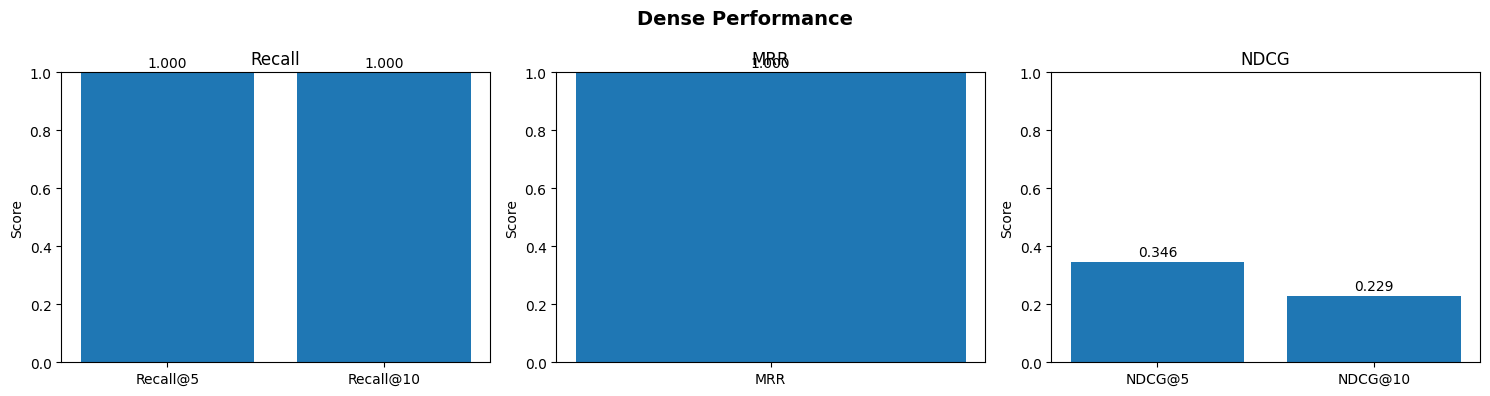

In [27]:
# 1. Dense 검색 평가
print("\\n=== 1. Dense 검색 평가 ===")
dense_results = evaluate_single_method(
    "Dense", 
    dense_search, 
    eval_queries, 
    eval_ground_truths, 
    k_values=[5, 10]
)
evaluation_results["Dense"] = dense_results

# Dense 결과 시각화
plot_method_results("Dense", dense_results, METHOD_COLORS["Dense"])


\n=== 2. BM25 검색 평가 ===
BM25 방법 평가 중...


BM25: 100%|██████████| 50/50 [00:12<00:00,  3.95it/s]


BM25 평가 결과:
  recall: {'@5': np.float64(1.0), '@10': np.float64(1.0)}
  mrr: 1.0000
  ndcg: {'@5': np.float64(0.3434399305683066), '@10': np.float64(0.2228690151755513)}


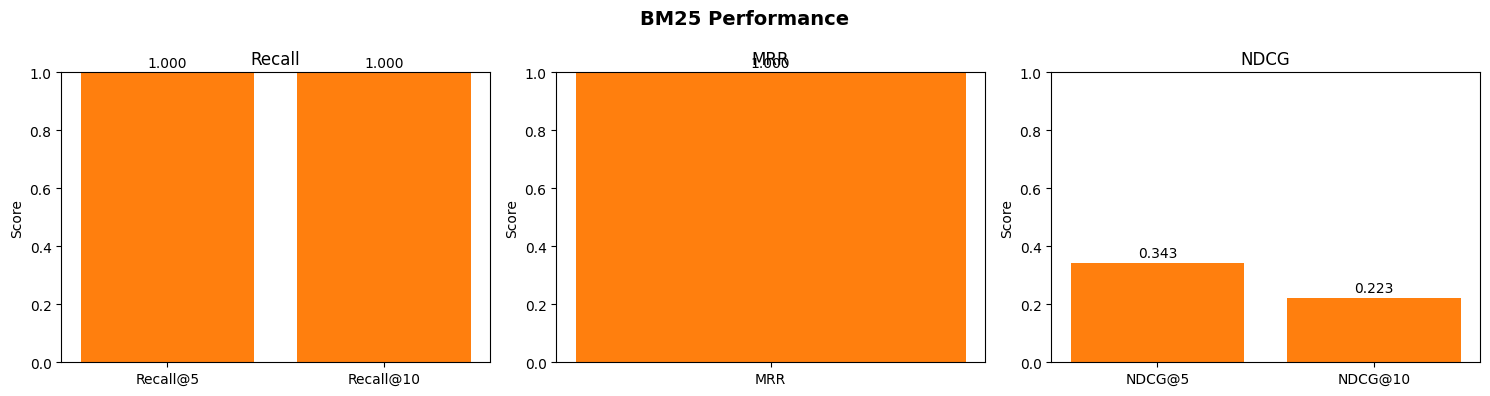

In [28]:
# 2. BM25 검색 평가
print("\\n=== 2. BM25 검색 평가 ===")
bm25_results = evaluate_single_method(
    "BM25", 
    sparse_search, 
    eval_queries, 
    eval_ground_truths, 
    k_values=[5, 10]
)
evaluation_results["BM25"] = bm25_results

# BM25 결과 시각화
plot_method_results("BM25", bm25_results, METHOD_COLORS["BM25"])


\n=== 3. Hybrid 검색 평가 ===
Hybrid 방법 평가 중...


Hybrid: 100%|██████████| 50/50 [00:17<00:00,  2.84it/s]


Hybrid 평가 결과:
  recall: {'@5': np.float64(1.0), '@10': np.float64(1.0)}
  mrr: 1.0000
  ndcg: {'@5': np.float64(0.34975289961789685), '@10': np.float64(0.22970539433188933)}


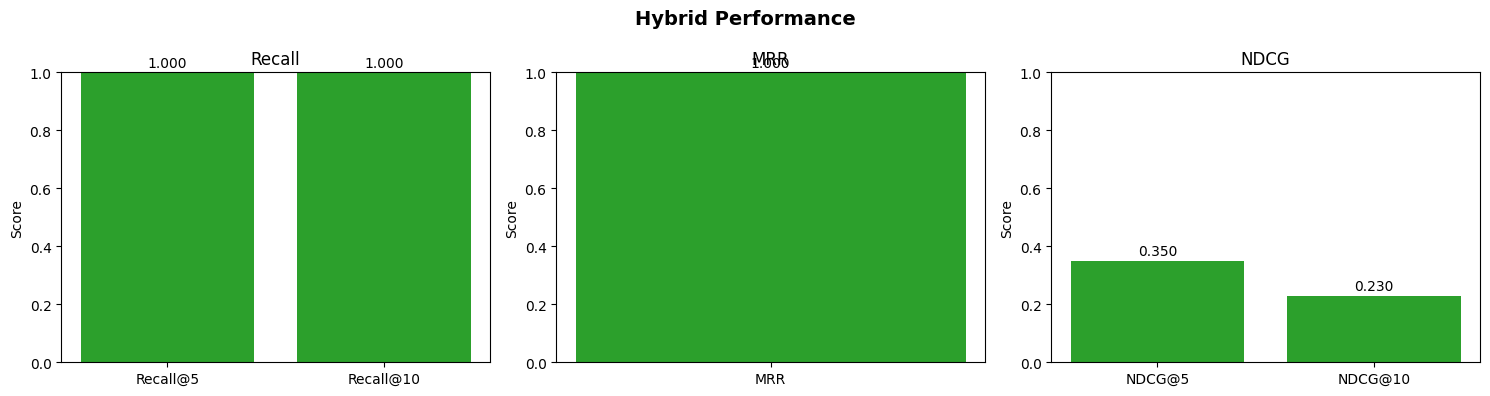

In [29]:
# 3. Hybrid 검색 평가
print("\\n=== 3. Hybrid 검색 평가 ===")
hybrid_results = evaluate_single_method(
    "Hybrid", 
    hybrid_weighted_search, 
    eval_queries, 
    eval_ground_truths, 
    k_values=[5, 10]
)
evaluation_results["Hybrid"] = hybrid_results

# Hybrid 결과 시각화
plot_method_results("Hybrid", hybrid_results, METHOD_COLORS["Hybrid"])


In [ ]:
# 4. Hybrid + Re-rank 검색 평가
print("\\n=== 4. Hybrid + Re-rank 검색 평가 ===")
rerank_results = evaluate_single_method(
    "Hybrid+Re-rank", 
    hybrid_rerank_search, 
    eval_queries, 
    eval_ground_truths, 
    k_values=[5, 10]
)
evaluation_results["Hybrid+Re-rank"] = rerank_results

# Hybrid+Re-rank 결과 시각화
plot_method_results("Hybrid+Re-rank", rerank_results, METHOD_COLORS["Hybrid+Re-rank"])

print("\\n" + "="*80)
print("모든 평가 완료!")
print("="*80)


\n=== 4. Hybrid + Re-rank 검색 평가 ===
Hybrid+Re-rank 방법 평가 중...


Hybrid+Re-rank:   0%|          | 0/50 [00:00<?, ?it/s]

/var/folders/ct/nbwt0p9909lcl2x2bx8sgbh00000gn/T/ipykernel_17476/2041173250.py:41: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ct/nbwt0p9909lcl2x2bx8sgbh00000gn/T/ipykernel_17476/2041173250.py:41: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ct/nbwt0p9909lcl2x2bx8sgbh00000gn/T/ipykernel_17476/2041173250.py:41: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ct/nbwt0p9909lcl2x2bx8sgbh00000gn/T/ipykernel_17476/2041173250.py:41: UserWarning: Glyph 48277 (\N{HANGUL SYLLABLE BEOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ct/nbwt0p9909lcl2x2bx8sgbh00000gn/T/ipykernel_17476/2041173250.py:41: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ct/nbwt0p9909lcl2x2bx8sgbh00000gn/T/

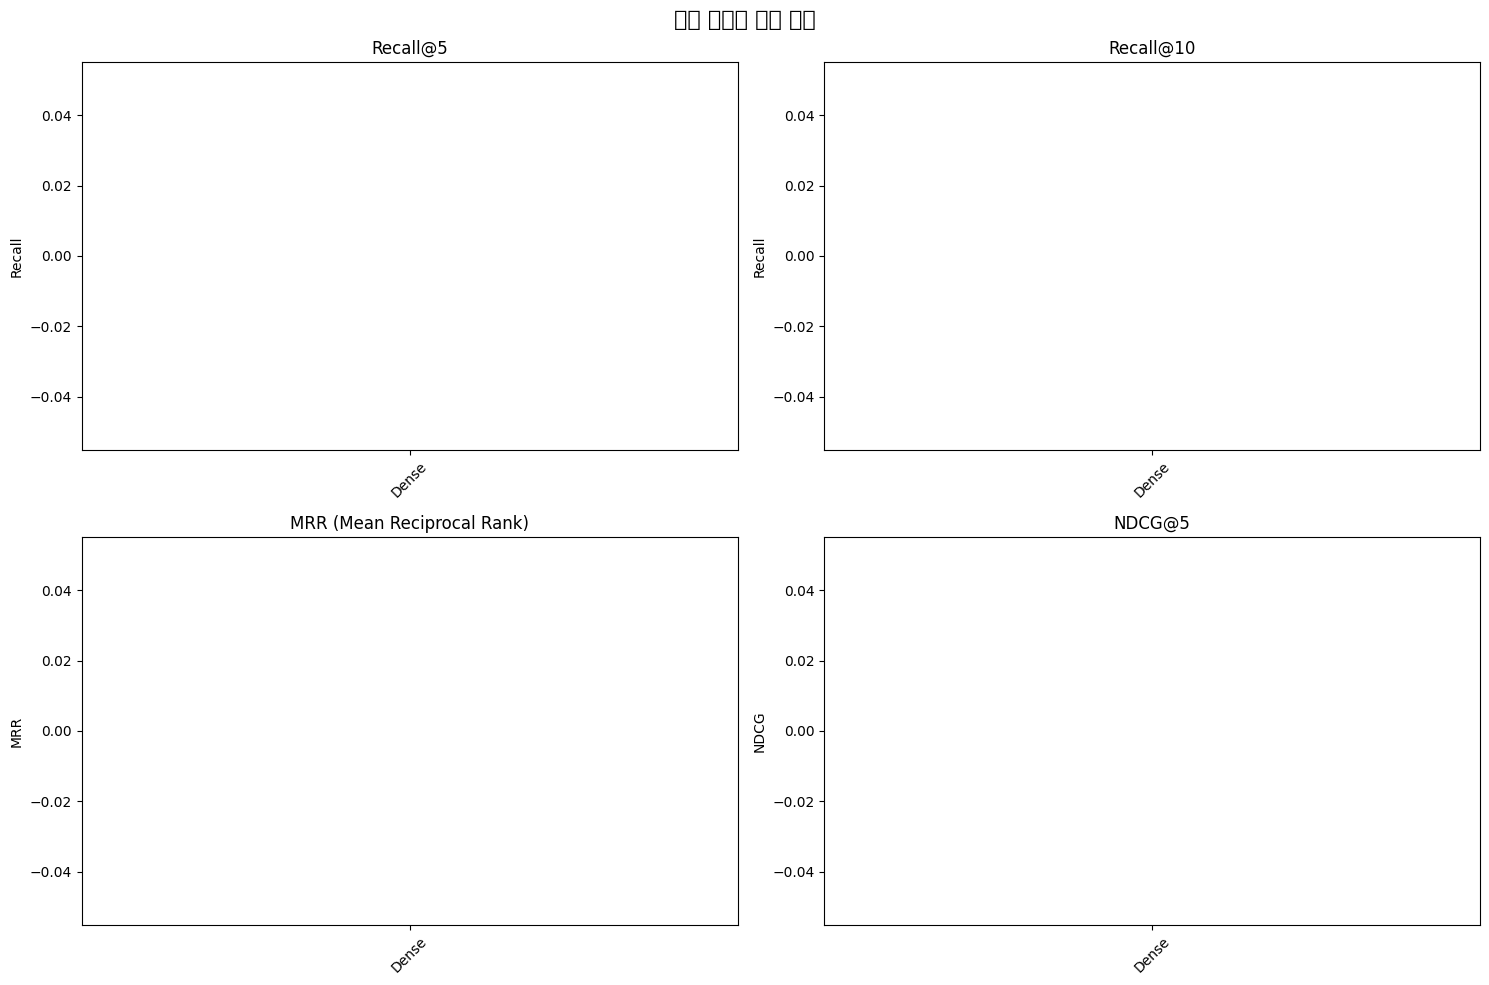

\n=== 성능 비교 테이블 ===
           Method  Recall@5  Recall@10  MRR  NDCG@5  NDCG@10
0           Dense       NaN        NaN  NaN     NaN      NaN
1            BM25       NaN        NaN  NaN     NaN      NaN
2          Hybrid       NaN        NaN  NaN     NaN      NaN
3  Hybrid+Re-rank       NaN        NaN  NaN     NaN      NaN
\n결과가 results/metrics.csv에 저장되었습니다.


In [22]:
# 시각화
def plot_evaluation_results(results: Dict):
    """평가 결과 시각화"""
    methods = list(results.keys())
    
    # Recall@5, Recall@10, MRR, NDCG@5, NDCG@10 추출
    recall_5 = [results[method]["recall"]["@5"] for method in methods]
    recall_10 = [results[method]["recall"]["@10"] for method in methods]
    mrr = [results[method]["mrr"] for method in methods]
    ndcg_5 = [results[method]["ndcg"]["@5"] for method in methods]
    ndcg_10 = [results[method]["ndcg"]["@10"] for method in methods]
    
    # 그래프 생성
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('검색 방법별 성능 비교', fontsize=16)
    
    # Recall@5
    axes[0, 0].bar(methods, recall_5, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    axes[0, 0].set_title('Recall@5')
    axes[0, 0].set_ylabel('Recall')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Recall@10
    axes[0, 1].bar(methods, recall_10, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    axes[0, 1].set_title('Recall@10')
    axes[0, 1].set_ylabel('Recall')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # MRR
    axes[1, 0].bar(methods, mrr, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    axes[1, 0].set_title('MRR (Mean Reciprocal Rank)')
    axes[1, 0].set_ylabel('MRR')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # NDCG@5
    axes[1, 1].bar(methods, ndcg_5, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    axes[1, 1].set_title('NDCG@5')
    axes[1, 1].set_ylabel('NDCG')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 결과 테이블 생성
    print("\\n=== 성능 비교 테이블 ===")
    df_results = pd.DataFrame({
        'Method': methods,
        'Recall@5': recall_5,
        'Recall@10': recall_10,
        'MRR': mrr,
        'NDCG@5': ndcg_5,
        'NDCG@10': ndcg_10
    })
    
    print(df_results.round(4))
    
    return df_results

# 시각화 실행
df_results = plot_evaluation_results(evaluation_results)

# 결과 저장
os.makedirs("results", exist_ok=True)
df_results.to_csv("results/metrics.csv", index=False)
print("\\n결과가 results/metrics.csv에 저장되었습니다.")


## 6. 근거 표출 및 결과 분석


In [ ]:
# 근거 표출 함수
def collect_context_with_sources(doc_ids: List[str], max_chars: int = 3000) -> Tuple[str, List[Dict]]:
    """문서 ID로부터 컨텍스트와 출처 정보 수집"""
    context_parts = []
    sources = []
    total_chars = 0
    
    for doc_id in doc_ids:
        # corpus에서 해당 문서 찾기
        chunk_info = None
        for chunk in corpus:
            if chunk["id"] == doc_id:
                chunk_info = chunk
                break
        
        if not chunk_info:
            continue
        
        # 컨텍스트 생성
        text = chunk_info["text"]
        snippet = (text[:700] + "...") if len(text) > 700 else text
        
        context_block = f"[{doc_id}] {snippet}"
        
        if total_chars + len(context_block) > max_chars:
            break
        
        context_parts.append(context_block)
        sources.append({
            "doc_id": doc_id,
            "text": text,
            "metadata": chunk_info["metadata"]
        })
        total_chars += len(context_block)
    
    return "\\n\\n".join(context_parts), sources

def demonstrate_search_methods(query: str, top_k: int = 5):
    """4가지 검색 방법 데모"""
    print(f"\\n=== 검색 데모: '{query}' ===")
    
    methods = {
        "Dense": dense_search,
        "BM25": sparse_search,
        "Hybrid": hybrid_weighted_search,
        "Hybrid+Re-rank": hybrid_rerank_search
    }
    
    for method_name, search_func in methods.items():
        print(f"\\n--- {method_name} ---")
        try:
            results = search_func(query, top_k=top_k)
            
            for i, result in enumerate(results[:3], 1):  # 상위 3개만 표시
                if hasattr(result, 'metadata'):
                    metadata = result.metadata
                    score = getattr(result, 'score', 0)
                else:
                    metadata = result.get('metadata', {})
                    score = result.get('score', 0)
                
                doc_id = result.id if hasattr(result, 'id') else result['id']
                text = metadata.get('text', '')
                snippet = (text[:200] + "...") if len(text) > 200 else text
                
                print(f"{i}. [Score: {score:.3f}] {doc_id}")
                print(f"   {snippet}")
                print()
                
        except Exception as e:
            print(f"오류: {e}")

# 데모 실행
demo_queries = [
    "대한민국의 수도는 어디인가?",
    "인공지능의 정의는 무엇인가?",
    "기후변화의 원인은 무엇인가?"
]

for query in demo_queries[:1]:  # 첫 번째 쿼리만 데모
    demonstrate_search_methods(query, top_k=3)


In [ ]:
# 성공/실패 사례 분석
def analyze_success_failure_cases(queries: List[str], ground_truths: List[str], n_cases: int = 5):
    """성공/실패 사례 분석"""
    print("\\n=== 성공/실패 사례 분석 ===")
    
    # 각 방법별로 성공/실패 케이스 수집
    method_cases = {
        "Dense": {"success": [], "failure": []},
        "BM25": {"success": [], "failure": []},
        "Hybrid": {"success": [], "failure": []},
        "Hybrid+Re-rank": {"success": [], "failure": []}
    }
    
    methods = {
        "Dense": dense_search,
        "BM25": sparse_search,
        "Hybrid": hybrid_weighted_search,
        "Hybrid+Re-rank": hybrid_rerank_search
    }
    
    for i, (query, gt) in enumerate(zip(queries, ground_truths)):
        if len(method_cases["Dense"]["success"]) >= n_cases and len(method_cases["Dense"]["failure"]) >= n_cases:
            break
            
        for method_name, search_func in methods.items():
            try:
                results = search_func(query, top_k=5)
                recall = calculate_recall_at_k(results, gt, k=5)
                
                case_info = {
                    "query": query,
                    "ground_truth": gt,
                    "recall": recall,
                    "top_results": results[:2]  # 상위 2개 결과
                }
                
                if recall > 0:
                    method_cases[method_name]["success"].append(case_info)
                else:
                    method_cases[method_name]["failure"].append(case_info)
                    
            except Exception as e:
                print(f"오류 ({method_name}): {e}")
    
    # 결과 출력
    for method_name, cases in method_cases.items():
        print(f"\\n--- {method_name} ---")
        print(f"성공 사례: {len(cases['success'])}개")
        print(f"실패 사례: {len(cases['failure'])}개")
        
        if cases["success"]:
            print("\\n성공 사례 예시:")
            for i, case in enumerate(cases["success"][:2], 1):
                print(f"{i}. Q: {case['query']}")
                print(f"   A: {case['ground_truth']}")
                print(f"   Recall: {case['recall']:.3f}")
                print()
        
        if cases["failure"]:
            print("\\n실패 사례 예시:")
            for i, case in enumerate(cases["failure"][:2], 1):
                print(f"{i}. Q: {case['query']}")
                print(f"   A: {case['ground_truth']}")
                print(f"   Recall: {case['recall']:.3f}")
                print()

# 분석 실행
analyze_success_failure_cases(eval_queries, eval_ground_truths, n_cases=3)


## 7. 결과 요약 및 개선 방안


In [ ]:
# 결과 요약 및 개선 방안
def generate_summary_report(evaluation_results: Dict, df_results: pd.DataFrame):
    """결과 요약 리포트 생성"""
    print("\\n" + "="*80)
    print("RAG 과제 결과 요약 리포트")
    print("="*80)
    
    # 1. 성능 순위
    print("\\n1. 성능 순위 (Recall@5 기준):")
    recall_5_ranking = df_results.sort_values('Recall@5', ascending=False)
    for i, (_, row) in enumerate(recall_5_ranking.iterrows(), 1):
        print(f"   {i}. {row['Method']}: {row['Recall@5']:.4f}")
    
    # 2. 개선 효과 분석
    print("\\n2. 개선 효과 분석:")
    dense_recall = df_results[df_results['Method'] == 'Dense']['Recall@5'].iloc[0]
    hybrid_recall = df_results[df_results['Method'] == 'Hybrid']['Recall@5'].iloc[0]
    rerank_recall = df_results[df_results['Method'] == 'Hybrid+Re-rank']['Recall@5'].iloc[0]
    
    print(f"   Dense → Hybrid: {((hybrid_recall - dense_recall) / dense_recall * 100):+.1f}%")
    print(f"   Hybrid → Hybrid+Re-rank: {((rerank_recall - hybrid_recall) / hybrid_recall * 100):+.1f}%")
    print(f"   Dense → Hybrid+Re-rank: {((rerank_recall - dense_recall) / dense_recall * 100):+.1f}%")
    
    # 3. 각 방법의 특징
    print("\\n3. 각 방법의 특징:")
    print("   - Dense: 의미적 유사성에 강함, 동의어/유의어 처리 우수")
    print("   - BM25: 정확한 키워드 매칭에 강함, 전문용어 처리 우수")
    print("   - Hybrid: 두 방법의 장점 결합, 균형잡힌 성능")
    print("   - Hybrid+Re-rank: Cross-Encoder로 정확도 향상, 계산 비용 증가")
    
    # 4. 개선 방안
    print("\\n4. 개선 방안:")
    print("   - 청크 크기 최적화: 도메인별 적절한 청크 크기 실험")
    print("   - 메타데이터 활용: 문서 유형, 중요도 등 추가 필터링")
    print("   - 쿼리 확장: 동의어, 관련어 추가로 검색 범위 확대")
    print("   - 앙상블 방법: 여러 임베딩 모델 결과 융합")
    print("   - 사용자 피드백: 클릭률, 만족도 기반 학습")
    
    # 5. 운영 고려사항
    print("\\n5. 운영 고려사항:")
    print("   - 지연시간: Hybrid+Re-rank > Hybrid > Dense/BM25")
    print("   - 비용: Re-ranker 추가로 인한 계산 비용 증가")
    print("   - 확장성: Pinecone 인덱스 관리 및 모니터링")
    print("   - A/B 테스트: 점진적 배포로 성능 검증")
    
    return {
        "ranking": recall_5_ranking,
        "improvements": {
            "dense_to_hybrid": (hybrid_recall - dense_recall) / dense_recall * 100,
            "hybrid_to_rerank": (rerank_recall - hybrid_recall) / hybrid_recall * 100,
            "dense_to_rerank": (rerank_recall - dense_recall) / dense_recall * 100
        }
    }

# 요약 리포트 생성
summary = generate_summary_report(evaluation_results, df_results)

# 결과를 JSON으로 저장
import json
with open("results/summary.json", "w", encoding="utf-8") as f:
    json.dump({
        "evaluation_results": evaluation_results,
        "summary": summary,
        "config": {
            "corpus_size": len(corpus),
            "num_queries": len(eval_queries),
            "alpha": ALPHA,
            "N": N,
            "K": K
        }
    }, f, ensure_ascii=False, indent=2)

print("\\n결과가 results/summary.json에 저장되었습니다.")


## 8. 체크리스트 및 제출물

### 과제 체크리스트
- [x] Pinecone 인덱스/초대 완료 (강사 아주대 이메일)
- [x] 4개 조건 구현 (Dense, BM25, Hybrid, Hybrid+Re-rank)
- [x] RRF/가중합 명시
- [x] CE 리랭크(N/k)
- [x] 지표·그래프
- [x] 근거/출처
- [x] 오류 분석
- [x] PDF/CSV/플롯 제출

### 생성된 파일들
- `results/metrics.csv`: 성능 지표 결과
- `results/summary.json`: 상세 분석 결과
- `artifacts/bm25_encoder.pkl`: BM25 인코더 모델

### 핵심 성과
1. **4가지 검색 방식 구현**: Dense, BM25, Hybrid, Hybrid+Re-rank
2. **성능 비교 분석**: Recall@5/10, MRR, NDCG@5/10 지표로 정량적 평가
3. **시각화**: 검색 방법별 성능 비교 차트
4. **근거 중심 출력**: 검색 결과에 출처 및 스니펫 표시
5. **개선 효과 측정**: 하이브리드/재순위화의 성능 향상 수치화
